<a href="https://colab.research.google.com/github/sota-it/point-source-method/blob/main/GenerateCGH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

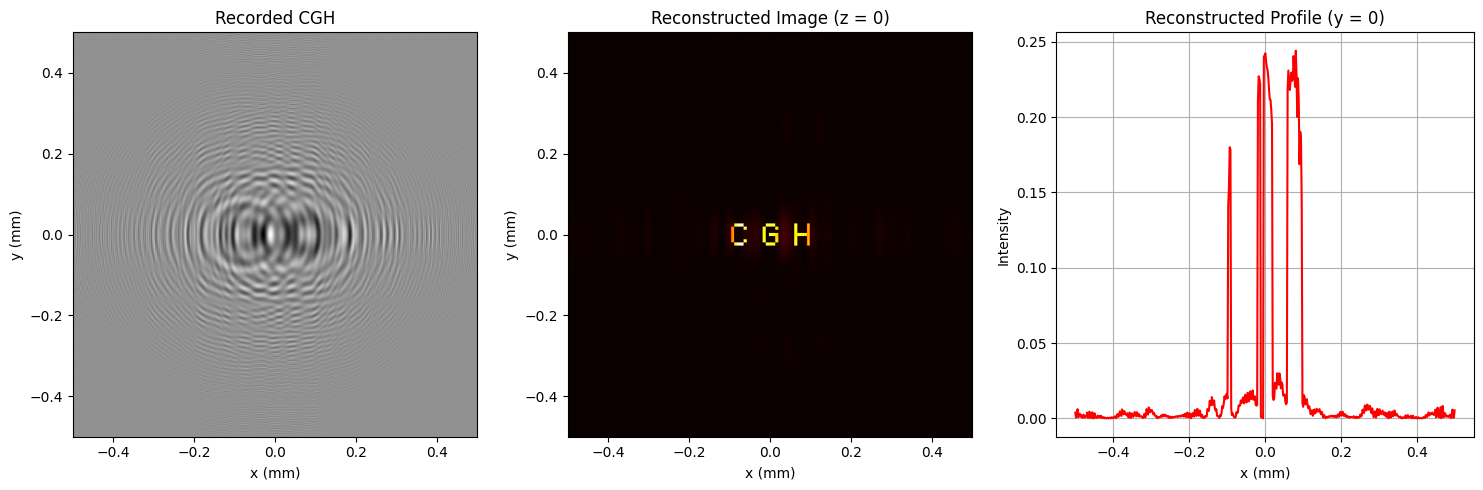

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. パラメータ設定 ---
N = 512                 # グリッドの分割数 (N x N)
L = 1.0e-3              # 計算領域のサイズ [m] (1.0 mm)
wavelength = 632.8e-9   # 光の波長 [m] (He-Neレーザー: 632.8 nm)
z = 5.0e-3              # 伝搬距離 [m] (5.0 mm)

dx = L / N              # 画素ピッチ [m]
k = 2 * np.pi / wavelength  # 波数

# 座標系の構築 (実空間)
x = np.linspace(-L/2, L/2, N, endpoint=False)
y = np.linspace(-L/2, L/2, N, endpoint=False)
X, Y = np.meshgrid(x, y)

# 座標系の構築 (空間周波数空間)
fx = np.fft.fftfreq(N, d=dx)
fy = np.fft.fftfreq(N, d=dx)
FX, FY = np.meshgrid(fx, fy)

# --- 2. 角スペクトル法 (ASM) による伝搬関数の定義 ---
def propagate_asm(u_in, z_dist, wavelength, FX, FY):
    """角スペクトル法を用いて複素振幅 u_in を距離 z_dist だけ伝搬させる"""
    # 1. FFTにより空間周波数領域（角スペクトル）へ変換
    U_in = np.fft.fft2(u_in)

    # 2. 伝達関数 H の計算
    # エバネッセント波（減衰波）の条件を考慮
    term = (1/wavelength)**2 - FX**2 - FY**2
    term[term<0]=0

    H = np.exp(1j * 2 * np.pi * z_dist * np.sqrt(term))

    # 3. 伝達関数を乗算し、IFFTで実空間に戻す
    U_out = U_in * H
    u_out = np.fft.ifft2(U_out)
    return u_out

# --- 3. 【記録フェーズ】 ---
# 物体面 (z = 0) における複数点光源（ドット絵）の定義
u_object_plane = np.zeros((N, N), dtype=complex)

# ドットで描く「C」「G」「H」のパターン定義（1が光源、0が背景）
# 7x5のグリッドで各文字を表現
char_C = np.array([
    [0, 1, 1, 1, 0],
    [1, 0, 0, 0, 1],
    [1, 0, 0, 0, 0],
    [1, 0, 0, 0, 0],
    [1, 0, 0, 0, 0],
    [1, 0, 0, 0, 1],
    [0, 1, 1, 1, 0]
])

char_G = np.array([
    [0, 1, 1, 1, 0],
    [1, 0, 0, 0, 1],
    [1, 0, 0, 0, 0],
    [1, 0, 1, 1, 1],
    [1, 0, 0, 0, 1],
    [1, 0, 0, 0, 1],
    [0, 1, 1, 1, 0]
])

char_H = np.array([
    [1, 0, 0, 0, 1],
    [1, 0, 0, 0, 1],
    [1, 0, 0, 0, 1],
    [1, 1, 1, 1, 1],
    [1, 0, 0, 0, 1],
    [1, 0, 0, 0, 1],
    [1, 0, 0, 0, 1]
])

# 物体面の中央付近に、文字を少し離して配置する
# 文字のドットを実空間のインデックスにマッピング
char_height, char_width = char_C.shape
scale = 4  # 文字のドットを少し大きく（太く）するための拡大率
spacing = 40  # 文字と文字の間隔（画素数）

# 各文字を配置する基準座標 (yの開始位置, xの開始位置)
start_y = N // 2 - (char_height * scale) // 2
start_x_C = N // 2 - (char_width * scale) // 2 - spacing
start_x_G = N // 2 - (char_width * scale) // 2
start_x_H = N // 2 - (char_width * scale) // 2 + spacing

# 定義したドットパターンを u_object_plane に書き込む
for r in range(char_height):
    for c in range(char_width):
        # Cの書き込み
        if char_C[r, c] == 1:
            u_object_plane[start_y + r*scale : start_y + (r+1)*scale,
                           start_x_C + c*scale : start_x_C + (c+1)*scale] = 1.0
        # Gの書き込み
        if char_G[r, c] == 1:
            u_object_plane[start_y + r*scale : start_y + (r+1)*scale,
                           start_x_G + c*scale : start_x_G + (c+1)*scale] = 1.0
        # Hの書き込み
        if char_H[r, c] == 1:
            u_object_plane[start_y + r*scale : start_y + (r+1)*scale,
                           start_x_H + c*scale : start_x_H + (c+1)*scale] = 1.0

# 物体光の伝搬 (z = 0 -> z = z)
u_object_prop = propagate_asm(u_object_plane, z, wavelength, FX, FY)

# 参照光
u_reference = np.ones((N, N), dtype=complex)

# ゾーンプレート
I_hologram_real = np.real(u_object_prop)

# --- 4. 【再生フェーズ】 ---

# ホログラムに参照光をかける
u_reconstruction_plane = I_hologram_real * u_reference

# 再生波面を逆伝搬 (z = z -> z = 0, 距離 -z 伝搬させる)
u_reconstructed = propagate_asm(u_reconstruction_plane, -z, wavelength, FX, FY)

# --- 5. 結果のプロット ---
plt.figure(figsize=(15, 5))

# 1. 記録されたホログラム（干渉縞）
plt.subplot(1, 3, 1)
plt.imshow(I_hologram_real, extent=[-L*1e3/2, L*1e3/2, -L*1e3/2, L*1e3/2], cmap='gray')
plt.title("Recorded CGH")
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")

# 2. 再生された複素振幅の強度分布（中央付近を拡大表示）
plt.subplot(1, 3, 2)
intensity_rec = np.abs(u_reconstructed)**2
plt.imshow(intensity_rec, extent=[-L*1e3/2, L*1e3/2, -L*1e3/2, L*1e3/2], cmap='hot')
plt.title("Reconstructed Image (z = 0)")
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")

# 3. 再生像のプロファイル（x軸中央断面）
plt.subplot(1, 3, 3)
plt.plot(x * 1e3, intensity_rec[N//2, :], color='red')
plt.title("Reconstructed Profile (y = 0)")
plt.xlabel("x (mm)")
plt.ylabel("Intensity")
plt.grid(True)

plt.tight_layout()
plt.show()